# Quickstart

Explore the main YAQS workflows with executable examples and their results.
After {doc}`installing YAQS <../installation>`, run the cells in a notebook. For
a standalone script, put the execution code inside an
`if __name__ == "__main__":` guard; see {doc}`simulator_initialization`.

The examples use `show_progress=False` to keep the documentation quiet. Omit
this argument to see progress. Times and rates use units consistent with each
Hamiltonian, with $\hbar=1$. Expand the plotting cells to reuse the figures.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib_inline.backend_inline import set_matplotlib_formats

set_matplotlib_formats("svg")
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["STIXGeneral"],
    "mathtext.fontset": "stix",
    "font.size": 11,
    "axes.labelsize": 11,
    "axes.linewidth": 0.7,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
    "legend.fontsize": 9,
    "legend.frameon": False,
    "lines.linewidth": 1.6,
    "lines.markersize": 4,
    "figure.figsize": (6.6, 3.0),
    "figure.constrained_layout.use": True,
    "savefig.dpi": 180,
})

## Noisy analog dynamics

Compare coherent transport and damping in a **20-site XY spin chain**. YAQS uses
an MPS and averages noisy dynamics over Monte Carlo trajectories.

In [2]:
from mqt.yaqs import AnalogSimParams, Hamiltonian, NoiseModel, Observable, Simulator, State

length = 20
center = length // 2
basis = "0" * center + "1" + "0" * (length - center - 1)
state = State(length, initial="basis", basis_string=basis)
hamiltonian = Hamiltonian.heisenberg(length, Jx=0.5, Jy=0.5, Jz=0.0)
params = AnalogSimParams(
    observables=[Observable("z", site) for site in range(length)],
    elapsed_time=3.0,
    dt=0.25,
    num_traj=32,
    preset="fast",
    random_seed=7,
)
relaxation_rate = 1.0
noise = NoiseModel([
    {"name": "lowering", "sites": [site], "strength": relaxation_rate} for site in range(length)
])

simulator = Simulator(show_progress=False)
coherent = simulator.run(state, hamiltonian, params)
dissipative = simulator.run(state, hamiltonian, params, noise)

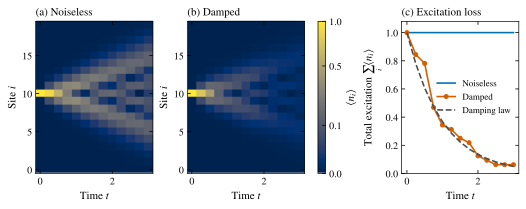

In [3]:
from matplotlib.colors import PowerNorm

occupation = np.stack([
    (1 - np.asarray(result.expectation_values).real) / 2
    for result in (coherent, dissipative)
])
fig, axes = plt.subplots(1, 3, figsize=(7.2, 2.8))
for ax, values, title in zip(
    axes[:2], occupation, ("(a) Noiseless", "(b) Damped"), strict=True,
):
    image = ax.pcolormesh(
        coherent.times, np.arange(length), values, shading="auto", cmap="cividis",
        norm=PowerNorm(0.5, vmin=0, vmax=1), rasterized=True,
    )
    ax.set(xlabel=r"Time $t$", ylabel=r"Site $i$")
    ax.set_title(title, loc="left", fontsize=11)
fig.colorbar(image, ax=list(axes[:2]), label=r"$\langle n_i\rangle$", ticks=[0, 0.1, 0.5, 1])
axes[2].plot(coherent.times, occupation[0].sum(axis=0), color="#0072B2", label="Noiseless")
axes[2].plot(coherent.times, occupation[1].sum(axis=0), "o-", color="#D55E00", label="Damped")
axes[2].plot(coherent.times, np.exp(-relaxation_rate * coherent.times), "--", color="0.3", label="Damping law")
axes[2].set(xlabel=r"Time $t$", ylabel=r"Total excitation $\sum_i\langle n_i\rangle$", ylim=(0, 1.08))
axes[2].set_title("(c) Excitation loss", loc="left", fontsize=11)
axes[2].legend()
plt.show()

The occupation $n_i=(1-Z_i)/2$ shows propagation and interference. Both heatmaps
use the same color scale, which emphasizes small occupations. Damping removes
excitations; the 32-trajectory estimate fluctuates around the exponential loss
law. This low-excitation state has limited entanglement. See
{doc}`analog_simulation` and {doc}`simulation_parameters` for larger budgets and
convergence checks.

## Noisy circuit readout

Prepare a **16-qubit graph state** and compare noiseless and damped readout.

In [4]:
from qiskit import QuantumCircuit

from mqt.yaqs import DigitalSimParams, NoiseModel, Simulator, State

num_qubits = 16
circuit = QuantumCircuit(num_qubits)
circuit.h(range(num_qubits))
for site in range(num_qubits - 1):
    circuit.cz(site, site + 1)
circuit.measure_all()

state = State(num_qubits, initial="zeros")
params = DigitalSimParams(shots=256, preset="fast", random_seed=7)
noise = NoiseModel([
    {"name": "lowering", "sites": [site], "strength": 0.5} for site in range(num_qubits)
])

simulator = Simulator(show_progress=False)
ideal = simulator.run(state, circuit, params)
damped = simulator.run(state, circuit, params, noise)

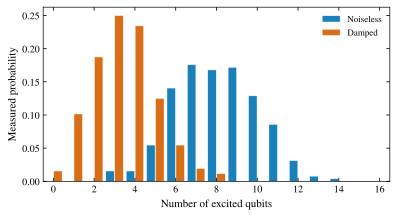

In [5]:
excitation_number = np.arange(num_qubits + 1)
readout_probabilities = []
fig, ax = plt.subplots(figsize=(5.4, 2.9))
for result, color, offset, label in (
    (ideal, "#0072B2", -0.22, "Noiseless"),
    (damped, "#D55E00", 0.22, "Damped"),
):
    probability = np.zeros(num_qubits + 1)
    for outcome, count in result.counts.items():
        probability[outcome.bit_count()] += count / params.shots
    readout_probabilities.append(probability)
    ax.bar(excitation_number + offset, probability, width=0.42, color=color,
           edgecolor="white", linewidth=0.5, alpha=0.9, label=label)
ax.set(xlabel="Number of excited qubits", ylabel="Measured probability",
       xlim=(-0.5, num_qubits + 0.5), xticks=np.arange(0, num_qubits + 1, 2))
ax.legend()
plt.show()

Damping shifts the readout toward fewer excitations. Each histogram summarizes
256 shots. See {doc}`circuit_shots` for bitstring counts and
{doc}`circuit_observables` for expectation values and OpenQASM input.

## Noisy Analog-Digital Simulation

Can digital gates reverse the spreading in an analog spin chain? Prepare one
excitation in a **20-site XY chain**, then apply $Z$ gates on even sites halfway
through the evolution. Compare free evolution, refocusing, and refocusing with
dephasing.

In [6]:
from qiskit import QuantumCircuit

from mqt.yaqs import AnalogSimParams, DigitalSimParams, Hamiltonian, NoiseModel, Observable, SimulationProgram, Simulator, State

length = 20
center = length // 2
state = State(length, initial="zeros")
hamiltonian = Hamiltonian.heisenberg(length, Jx=0.5, Jy=0.5, Jz=0.0)
observables = [Observable("z", site) for site in range(length)]
preparation = QuantumCircuit(length)
preparation.x(center)
phase_pulse = QuantumCircuit(length)
phase_pulse.z(range(0, length, 2))

analog_params = AnalogSimParams(elapsed_time=1.5, dt=0.25, order=2, preset="fast")
digital_params = DigitalSimParams(preset="fast")
free_program = SimulationProgram(
    [(preparation, digital_params), (hamiltonian, analog_params), (hamiltonian, analog_params)],
    observables=observables, num_traj=32, random_seed=7,
)
echo_program = SimulationProgram(
    [(preparation, digital_params), (hamiltonian, analog_params),
     (phase_pulse, digital_params), (hamiltonian, analog_params), (phase_pulse, digital_params)],
    observables=observables, num_traj=32, random_seed=7,
)
dephasing_rate = 0.2
noise = NoiseModel([
    {"name": "pauli_z", "sites": [site], "strength": dephasing_rate} for site in range(length)
])

simulator = Simulator(show_progress=False)
free_result = simulator.run(state, free_program)
echo_result = simulator.run(state, echo_program)
noisy_echo_result = simulator.run(state, echo_program, noise_model=noise)

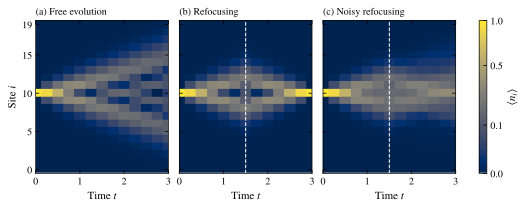

In [7]:
from matplotlib.colors import PowerNorm

fig, axes = plt.subplots(1, 3, figsize=(7.2, 2.8), sharex=True, sharey=True)
for index, (ax, result, title) in enumerate(zip(
    axes, (free_result, echo_result, noisy_echo_result),
    ("(a) Free evolution", "(b) Refocusing", "(c) Noisy refocusing"), strict=True,
)):
    segments = [segment for segment in result.segment_results if segment.segment_type == "analog"]
    times = np.concatenate([segment.times + segment.time_offset for segment in segments])
    values = np.concatenate([np.asarray(segment.expectation_values) for segment in segments], axis=1)
    keep = np.r_[True, np.diff(times) > 0]
    occupation = (1 - values[:, keep]) / 2
    image = ax.pcolormesh(
        times[keep], np.arange(length), occupation, shading="auto", cmap="cividis",
        norm=PowerNorm(0.5, vmin=0, vmax=1), rasterized=True,
    )
    if index > 0:
        ax.axvline(1.5, color="white", linestyle="--", linewidth=1)
    ax.set(xlabel=r"Time $t$", xlim=(0, 3), yticks=[0, 5, 10, 15, 19])
    ax.set_title(title, loc="left", fontsize=10)
axes[0].set_ylabel(r"Site $i$")
fig.colorbar(image, ax=list(axes), label=r"$\langle n_i\rangle$", ticks=[0, 0.1, 0.5, 1])
plt.show()

The phase pulse reverses the XY exchange, bringing the excitation back at $t=3$.
A final pulse restores the phase frame. Dephasing during the analog intervals
preserves excitation but disrupts refocusing; the noisy panel averages 32
trajectories at Lindblad rate $\gamma_z=0.2$. The gates are ideal and
instantaneous. All panels share one color scale. See
{doc}`digital_analog_simulation` for the pulse mechanism, program outputs, and
noise comparisons.

## Circuit equivalence

Verify a transpiled circuit, then compare the effects of an added rotation and
increasing Pauli noise.

In [8]:
import numpy as np
from qiskit import QuantumCircuit, transpile

from mqt.yaqs import EquivalenceChecker, NoiseModel

circuit = QuantumCircuit(4)
circuit.h(0)
for site in range(3):
    circuit.cx(site, site + 1)
decomposed = transpile(circuit, basis_gates=["rz", "sx", "x", "cx"])

checker = EquivalenceChecker()
print("Equivalent:", checker.check(circuit, decomposed)["equivalent"])
angles = np.linspace(0, np.pi, 17)
rotation_overlaps = []
for angle in angles:
    perturbed = decomposed.copy()
    perturbed.rz(float(angle), 0)
    rotation_overlaps.append(checker.check(circuit, perturbed)["fidelity"])

error_probabilities = np.linspace(0, 0.9, 10)
noisy_checks = []
for probability in error_probabilities:
    noise = NoiseModel([{"name": "pauli_z", "sites": [0], "strength": float(probability)}])
    noisy_checks.append(checker.check(
        circuit, decomposed, noise_model=noise, num_traj=128, random_seed=7,
    ))

Equivalent: True


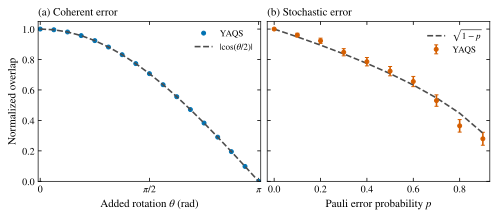

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(6.8, 2.9), sharey=True)
axes[0].plot(angles, rotation_overlaps, "o", color="#0072B2", label="YAQS")
axes[0].plot(angles, np.abs(np.cos(angles / 2)), "--", color="0.3", label=r"$|\cos(\theta/2)|$")
axes[0].set(xlabel=r"Added rotation $\theta$ (rad)", ylabel="Normalized overlap",
            xlim=(-0.03, np.pi + 0.03), ylim=(0, 1.05), xticks=[0, np.pi / 2, np.pi],
            xticklabels=["0", r"$\pi/2$", r"$\pi$"])
axes[0].set_title("(a) Coherent error", loc="left", fontsize=11)
axes[0].legend()
axes[1].errorbar(error_probabilities, [check["fidelity"] for check in noisy_checks],
                 yerr=[check["fidelity_error"] for check in noisy_checks],
                 fmt="o", color="#D55E00", capsize=2, label="YAQS")
axes[1].plot(error_probabilities, np.sqrt(1 - error_probabilities), "--", color="0.3", label=r"$\sqrt{1-p}$")
axes[1].set(xlabel=r"Pauli error probability $p$", xlim=(-0.03, 0.93))
axes[1].set_title("(b) Stochastic error", loc="left", fontsize=11)
axes[1].legend()
plt.show()

An overlap of one indicates agreement up to a global phase. Here, site 0 has one
noise opportunity, after the first CX gate. A $Z$ error has zero overlap, so the
ensemble's root-mean-square overlap is $\sqrt{1-p}$. Error bars show Monte Carlo
standard errors. Noise is applied to the second circuit. See
{doc}`equivalence_checking` for supported noise and accuracy controls.

## Environmental memory

Sweep the Ising coupling in a three-spin chain and compare the probe qubit's
memory spectra using the same probe grid.

In [10]:
import numpy as np

from mqt.yaqs import AnalogSimParams, Hamiltonian, MemoryCharacterizer

couplings = np.linspace(0, 1.5, 13)
params = AnalogSimParams(elapsed_time=0.5, dt=0.5, preset="fast")
characterizer = MemoryCharacterizer(show_progress=False)
memories = []
for coupling in couplings:
    hamiltonian = Hamiltonian.ising(3, J=coupling, g=1.0)
    memories.append(characterizer.characterize(
        hamiltonian, params, num_interventions=4, cut=2, preset="quick",
        rng=np.random.default_rng(7),
    ))

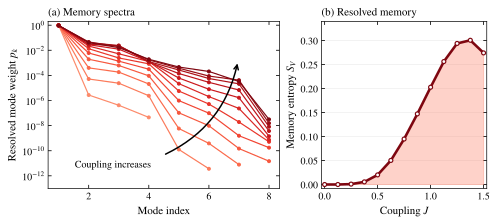

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(6.8, 3.0), width_ratios=[1.4, 1])
colors = plt.colormaps["Reds"](np.linspace(0.35, 0.95, len(couplings)))
for memory, color in zip(memories, colors, strict=True):
    spectrum = memory.singular_values(2)
    weights = spectrum**2 / np.sum(spectrum**2)
    axes[0].semilogy(np.arange(1, len(weights) + 1), weights, "o-",
                     color=color, linewidth=1.2, markersize=3)
axes[0].text(0.28, 0.14, "Coupling increases", transform=axes[0].transAxes,
             ha="center", va="center", fontsize=10, color="black")
axes[0].annotate("", xy=(0.82, 0.76), xytext=(0.50, 0.20),
                 xycoords="axes fraction",
                 arrowprops={"arrowstyle": "->", "color": "black",
                             "lw": 1.5, "connectionstyle": "arc3,rad=0.25"})
axes[0].set(xlabel="Mode index", ylabel=r"Resolved mode weight $p_k$", ylim=(1e-13, 2))
axes[0].set_title("(a) Memory spectra", loc="left", fontsize=11)
entropies = np.array([memory.entropy(2) for memory in memories])
axes[1].fill_between(couplings, entropies, color=colors[3], alpha=0.3)
axes[1].plot(couplings, entropies, "o-", color=colors[-1], linewidth=2.6,
             markerfacecolor="white", markeredgewidth=1.2)
axes[1].set(xlabel=r"Coupling $J$", ylabel=r"Memory entropy $S_V$",
            xlim=(-0.03, 1.53), ylim=(-0.008, 0.34), xticks=[0, 0.5, 1, 1.5])
axes[1].grid(axis="y", color="0.9", linewidth=0.5)
axes[1].set_axisbelow(True)
axes[1].set_title("(b) Resolved memory", loc="left", fontsize=11)
plt.show()

The weights $p_k=s_k^2/\sum_j s_j^2$ describe memory resolved by the sampled
probes. Darker curves show larger $J$. Coupling redistributes weight among the
resolved modes. The entropy measures this spread and peaks within this sweep.
These weights are not environment-state populations. See {doc}`characterization`
for probe choices and interpretation.

## Create a digital twin

Learn
**relaxation and dephasing from measurements at the ends of a spin chain**. Then
rerun the fitted model to predict transport through the unmeasured interior.

In [12]:
import numpy as np

from mqt.yaqs import AnalogSimParams, Hamiltonian, NoiseCharacterizer, NoiseModel, Observable, Simulator, State

length = 4
state = State(length, initial="basis", basis_string="1000", representation="density_matrix")
hamiltonian = Hamiltonian.heisenberg(length, Jx=0.5, Jy=0.5, Jz=0.0)
observables = [Observable("z", site) for site in range(length)]
params = AnalogSimParams(observables=observables, elapsed_time=8.0, dt=0.1, preset="fast")
reference = NoiseModel([
    {"name": "lowering", "sites": [3], "strength": 0.35},
    {"name": "pauli_z", "sites": [2], "strength": 0.12},
])
guess = NoiseModel([
    {"name": "lowering", "sites": [3], "strength": 0.2},
    {"name": "pauli_z", "sites": [2], "strength": 0.2},
])

simulator = Simulator(show_progress=False)
measured = simulator.run(state, hamiltonian, params, reference)
characterizer = NoiseCharacterizer(show_progress=False)
fit = characterizer.characterize(
    hamiltonian,
    params,
    init_state=state,
    init_guess=guess,
    observables=[observables[0], observables[-1]],
    ref_expectations=np.asarray(measured.expectation_values)[[0, -1]],
    x_low=np.zeros(2),
    x_up=np.ones(2),
    max_iter=40,
    seed=7,
)
reconstructed = simulator.run(state, hamiltonian, params, fit.optimal_model)
print("Fitted rates:", fit.best_parameters.round(3))

Fitted rates: [0.35 0.12]


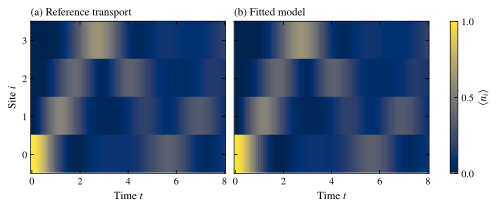

In [13]:
reference_dynamics = (1 - np.asarray(measured.expectation_values).real) / 2
fitted_dynamics = (1 - np.asarray(reconstructed.expectation_values).real) / 2
fig, axes = plt.subplots(1, 2, figsize=(6.8, 2.8), sharey=True)
for ax, dynamics, title in zip(
    axes, (reference_dynamics, fitted_dynamics),
    ("(a) Reference transport", "(b) Fitted model"), strict=True,
):
    image = ax.pcolormesh(measured.times, np.arange(length), dynamics,
                          shading="auto", cmap="cividis", vmin=0, vmax=1, rasterized=True)
    ax.set(xlabel=r"Time $t$", yticks=np.arange(length))
    ax.set_title(title, loc="left", fontsize=11)
axes[0].set_ylabel(r"Site $i$")
fig.colorbar(image, ax=list(axes), label=r"$\langle n_i\rangle$", ticks=[0, 0.5, 1])
plt.show()

The excitation propagates and reflects while a local sink removes population and
dephasing changes transport. Only sites 0 and 3 enter the fit; sites 1 and 2
check its predictions. Both heatmaps share a scale. This example uses synthetic
observations without measurement noise from density-matrix simulation; replace
the reference array with your measured traces. The fit assumes the two channel
types and their sites are known. See {doc}`digital_twin` for data preparation
and validation.

## Predict non-Markovian dynamics

YAQS also provides experimental surrogate models that learn a probe's response
to controls from simulated training sequences. See {doc}`memory_surrogate` for a
small example with an independent reference. This feature is not yet supported
by a published YAQS paper; validate predictions for your controls and time
horizon.

## Next steps

| Task                                   | Guide                            |
| -------------------------------------- | -------------------------------- |
| Choose accuracy settings               | {doc}`simulation_parameters`     |
| Choose states and simulation backends  | {doc}`state_initialization`      |
| Combine analog evolution and circuits  | {doc}`digital_analog_simulation` |
| Check whether two circuits agree       | {doc}`equivalence_checking`      |
| Create a digital twin                  | {doc}`digital_twin`              |
| Study memory in a system's environment | {doc}`characterization`          |
| Predict non-Markovian dynamics         | {doc}`memory_surrogate`          |